#Project Plan: End-to-End Data Science for Crop Production Efficiency

##1. Problem Definition
Objective: Determine how efficiently different regions (Africa, Americas, Asia, Europe, Oceania) produce crops by calculating yield (production per unit area) and analyzing trends over time (2013–2023).



In [1]:
import pandas as pd

# Load the data
data = pd.read_csv("Top 11 crop production as per the regions for 11 yrs.csv")

In [2]:
data.head()

,Domain,Area,Element,Item,Year,Unit,Value
0,Crops and livestock products,Africa,Area harvested,Bananas,2013,ha,1918733.00
1,Crops and livestock products,Africa,Production,Bananas,2013,t,20563373.67
2,Crops and livestock products,Africa,Area harvested,Bananas,2014,ha,1991075.00
3,Crops and livestock products,Africa,Production,Bananas,2014,t,19798302.75
4,Crops and livestock products,Africa,Area harvested,Bananas,2015,ha,1964307.00


In [3]:
# Pivot the data to separate Production and Area harvested
pivot_data = data.pivot_table(
    index=['Domain', 'Area', 'Item', 'Year'],
    columns='Element',
    values='Value',
    aggfunc='sum'
).reset_index()


In [4]:
# Rename columns for clarity
pivot_data.columns = ['Domain', 'Region', 'Crop', 'Year', 'Area_harvested', 'Production']

##Efficiency Metric: Yield = Production (tonnes) / Area harvested (hectares).

In [5]:
# Calculate yield (tonnes per hectare)
pivot_data['Yield'] = pivot_data['Production'] / pivot_data['Area_harvested']

In [6]:
# Handle missing values (if any)
pivot_data = pivot_data.dropna()

In [7]:
# Save the cleaned dataset
pivot_data.to_csv("cleaned_crop_data.csv", index=False)

print(pivot_data.head())

                         Domain  Region     Crop  Year  Area_harvested  \
0  Crops and livestock products  Africa  Bananas  2013       1918733.0   
1  Crops and livestock products  Africa  Bananas  2014       1991075.0   
2  Crops and livestock products  Africa  Bananas  2015       1964307.0   
3  Crops and livestock products  Africa  Bananas  2016       1883443.0   
4  Crops and livestock products  Africa  Bananas  2017       1760862.0   

    Production      Yield  
0  20563373.67  10.717163  
1  19798302.75   9.943524  
2  19710855.65  10.034509  
3  19233873.50  10.212082  
4  18973766.88  10.775272  


In [8]:
# Replace the Domain value
pivot_data['Domain'] = pivot_data['Domain'].replace('Crops and livestock products', 'Crops')

# Save the modified file
pivot_data.to_csv('Modified_Crop_Production_Data.csv', index=False)

In [9]:
pivot_data.head()

,Domain,Region,Crop,Year,Area_harvested,Production,Yield
0,Crops,Africa,Bananas,2013,1918733.0,20563373.67,10.717163
1,Crops,Africa,Bananas,2014,1991075.0,19798302.75,9.943524
2,Crops,Africa,Bananas,2015,1964307.0,19710855.65,10.034509
3,Crops,Africa,Bananas,2016,1883443.0,19233873.50,10.212082
4,Crops,Africa,Bananas,2017,1760862.0,18973766.88,10.775272


In [10]:
pivot_data.tail()

,Domain,Region,Crop,Year,Area_harvested,Production,Yield
577,Crops,Oceania,Wheat,2019,10447426.0,17995761.79,1.722507
578,Crops,Oceania,Wheat,2020,9908969.0,14934020.04,1.507121
579,Crops,Oceania,Wheat,2021,12686902.0,32345470.20,2.549517
580,Crops,Oceania,Wheat,2022,12771132.0,36640039.23,2.868973
581,Crops,Oceania,Wheat,2023,12965815.0,41591113.37,3.207752


##Exploratory Data Analysis (EDA) with visualizations (e.g., yield trends, regional comparisons).

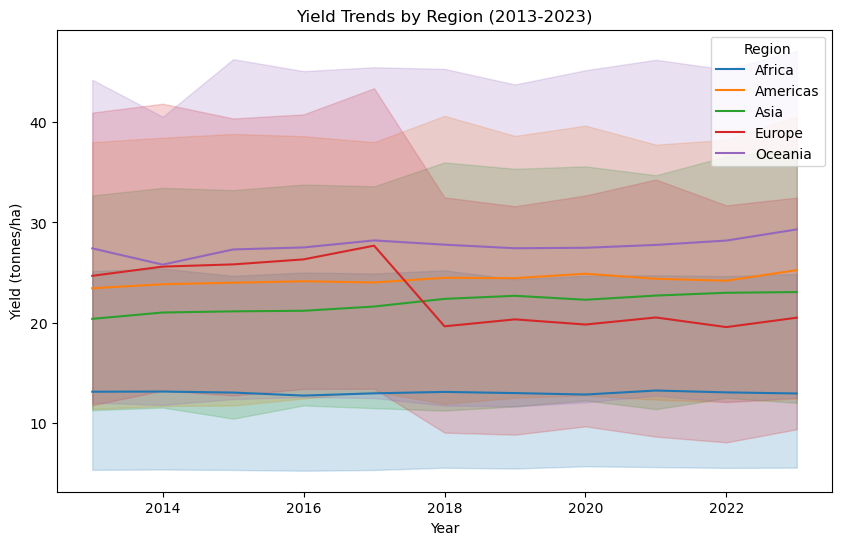

In [11]:
import matplotlib.pyplot as plt
import seaborn as sns

# Yield trends by region
plt.figure(figsize=(10, 6))
sns.lineplot(data=pivot_data, x='Year', y='Yield', hue='Region')
plt.title('Yield Trends by Region (2013-2023)')
plt.xlabel('Year')
plt.ylabel('Yield (tonnes/ha)')
plt.savefig('yield_trends_by_region.png')
plt.show()

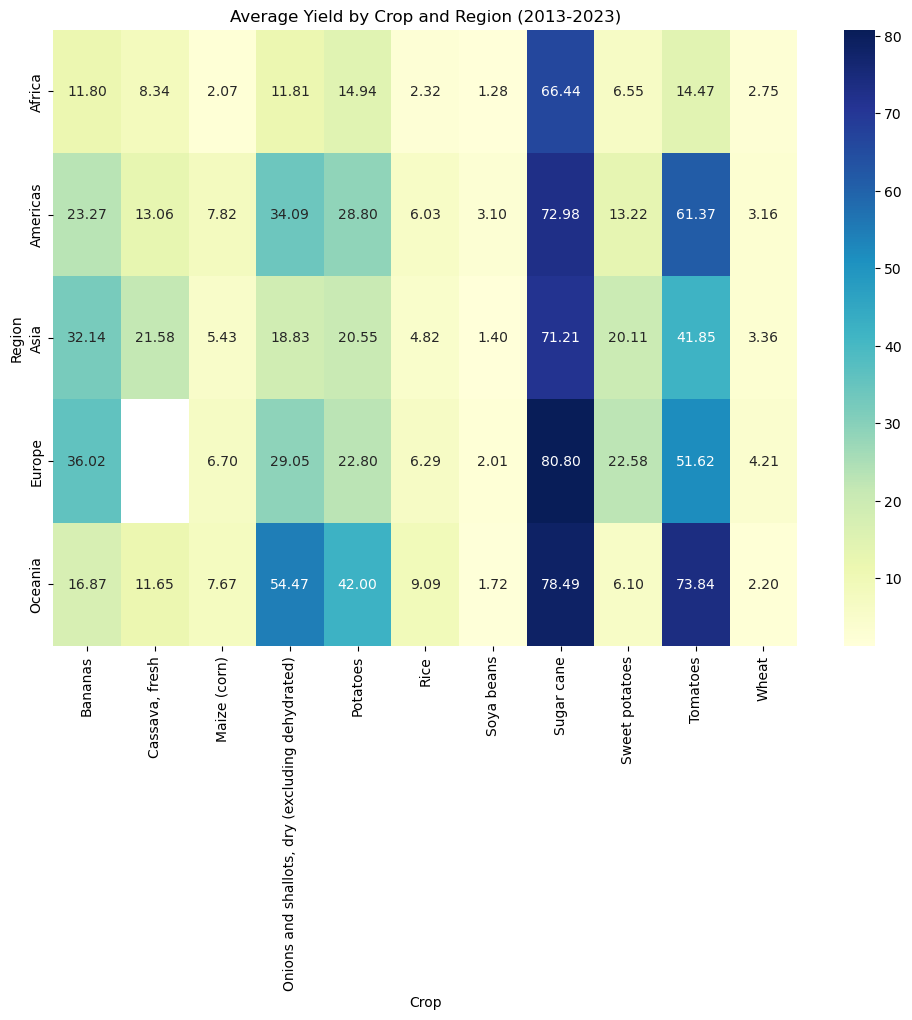

In [12]:
# Average yield by crop and region
avg_yield = pivot_data.groupby(['Region', 'Crop'])['Yield'].mean().unstack()
plt.figure(figsize=(12, 8))
sns.heatmap(avg_yield, annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Average Yield by Crop and Region (2013-2023)')
plt.savefig('yield_heatmap.png')
plt.show()

##Insights


*   Americas are producing higher yield of Sybeans.
*   Europe produces more yield of Bananas.

*   Africa are the least produceers in all the regions.

###  From 2013 to 2017 Europe were doing well in producing Agricultural yields. Then A sharp decline in productions due to the following reasons.
*   In 2018, Europe experienced a *sharp decline in agricultural production* primarily due to *extreme weather events* linked to climate change. Here are the key factors that contributed to the drop:

 1. *Severe Drought & Heatwaves*  
   - Many parts of *Northern and Central Europe* (Germany, France, the Netherlands, Poland, the Baltics, and Scandinavia) faced an *exceptionally dry and hot summer*.  
   - Rainfall deficits reached *50-80% below average* in some regions, leading to *parched soils and reduced crop yields*.  
   - The drought was one of the worst in decades, with *Germany declaring a state of emergency* in some agricultural areas.  

  2. *Crop Failures*  
   - *Cereal production (wheat, barley, maize) dropped significantly—Germany saw a **20% decline, while Sweden and the Baltics lost up to **50% of their harvests*.  
   - *Potato and sugar beet yields* were severely affected, leading to price increases.  
   - *Forage shortages* for livestock led to farmers culling herds or buying expensive feed imports.  

  3. *Wildfires & Soil Degradation*  
   - *Scandinavia and the UK* experienced unusual wildfires, further damaging farmland.  
   - Prolonged dryness reduced soil fertility, affecting future planting seasons.  

  4. *Economic Impact*  
   - The EU’s farming sector suffered *losses in the billions of euros*.  
   - Some farmers relied on *EU emergency aid* and insurance payouts.  

### *Long-Term Implications*  
The 2018 crisis highlighted Europe’s vulnerability to *climate change-induced weather extremes, pushing policymakers to focus on **drought-resistant crops and better water management*







In [13]:
# Top crops by yield
top_crops = pivot_data.groupby('Crop')['Yield'].mean().sort_values(ascending=False)
print("Top Crops by Average Yield:")
print(top_crops)

Top Crops by Average Yield:
Crop
Sugar cane                                         73.149846
Tomatoes                                           48.630451
Onions and shallots, dry (excluding dehydrated)    29.649464
Potatoes                                           25.819457
Bananas                                            24.022076
Cassava, fresh                                     13.655665
Sweet potatoes                                     12.627210
Maize (corn)                                        5.936948
Rice                                                5.709241
Wheat                                               3.136537
Soya beans                                          1.903940
Name: Yield, dtype: float64


##Predictive model (This is optional, e.g., forecasting future yields).

In [14]:
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.preprocessing import LabelEncoder

# Encode categorical variables
le_region = LabelEncoder()
le_crop = LabelEncoder()
pivot_data['Region_encoded'] = le_region.fit_transform(pivot_data['Region'])
pivot_data['Crop_encoded'] = le_crop.fit_transform(pivot_data['Crop'])

In [15]:
# Features and target
X = pivot_data[['Region_encoded', 'Crop_encoded', 'Year', 'Area_harvested']]
y = pivot_data['Yield']

In [16]:
# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
model = RandomForestRegressor(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

RandomForestRegressor(random_state=42)

In [17]:
# Evaluate
print("R² Score:", model.score(X_test, y_test))

R² Score: 0.9872514663096907


In [18]:
# Save model
import joblib
joblib.dump(model, 'yield_model.pkl')

['yield_model.pkl']

#Streamlit App Code:

In [20]:
%pip install streamlit
%pip install plotly
import streamlit as st
import pandas as pd
import plotly.express as px
import joblib

# Load data and model
data = pd.read_csv("cleaned_crop_data.csv")
model = joblib.load("yield_model.pkl")

# Title
st.title("Crop Production Efficiency Analysis")

# Sidebar filters
region = st.sidebar.selectbox("Select Region", data['Region'].unique())
crop = st.sidebar.selectbox("Select Crop", data['Crop'].unique())

# Filter data
filtered_data = data[(data['Region'] == region) & (data['Crop'] == crop)]

# Yield trend plot
fig = px.line(filtered_data, x='Year', y='Yield', title=f'Yield Trend for {crop} in {region}')
st.plotly_chart(fig)

# Predict yield (optional)
if st.button("Predict Yield for 2024"):
    input_data = pd.DataFrame({
        'Region_encoded': [le_region.transform([region])[0]],
        'Crop_encoded': [le_crop.transform([crop])[0]],
        'Year': [2024],
        'Area_harvested': [filtered_data['Area_harvested'].mean()]
    })
    prediction = model.predict(input_data)[0]
    st.write(f"Predicted Yield for 2024: {prediction:.2f} tonnes/ha")

Note: you may need to restart the kernel to use updated packages.
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
   ---------------------------------------- 0.0/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
    --------------------------------------- 0.3/14.8 MB ? eta -:--:--
   - -------------------------------------- 0.5/14.8 MB 799.2 kB/s eta 0:00:18
   -- ------------------------------------- 0.8/14.8 MB 860.9 kB/s eta 0:00:17
   -- ------------------------------------- 1.0/14.8 MB 949.8 kB/s eta 0:00:15
   --- ------------------------------------ 1.3/14.8 MB 1.0 MB/s eta 0:00:14
   ---- ----------------------------------- 1.6/14.8 MB 1.0 MB/s eta 0:00:13
   ---- ----------------------------------- 1.8/14.8 MB 1.1 MB/s eta 0:00:12
   ----- ---------------------------------- 2.1/14.8 MB 1.1 MB/s eta 0:00:12
   ------ -----------------------------

2025-05-01 14:53:37.547 WARNING streamlit.runtime.scriptrunner_utils.script_run_context: Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:53:38.629 
  command:

    streamlit run c:\Users\AUSTIN\Desktop\Heart Disease Prediction\.conda\lib\site-packages\ipykernel_launcher.py [ARGUMENTS]
2025-05-01 14:53:38.630 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:53:38.632 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:53:38.634 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:53:38.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:53:38.640 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2025-05-01 14:53